In [1]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

## Get Baseline

In [3]:
def spatial_subset(ds):
    out = ds.sel(lon=slice(349.5, 356.5),
                lat=slice(35.5, 42.3))
    return out

In [4]:
baseline_df = pd.DataFrame()
for year in range(1991, 2022):

    var = xr.open_dataset(f"/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011
Opening 2012
Opening 2013
Opening 2014
Opening 2015
Opening 2016
Opening 2017
Opening 2018
Opening 2019
Opening 2020
Opening 2021


In [5]:
y2022 = xr.open_dataset("/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2022.nc", 
                        engine="netcdf4", decode_times=True)
y2023 = xr.open_dataset("/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)
y2024 = xr.open_dataset("/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2024.nc", 
                        engine="netcdf4", decode_times=True)
y2025 = xr.open_dataset("/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2025.nc", 
                        engine="netcdf4", decode_times=True)

print(y2023)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...


In [6]:
y2022_sel = spatial_subset(y2022)
y2022_sst = y2022_sel["sst"]
y2022_time = y2022_sel["time"]

y2023_sel = spatial_subset(y2023)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

y2024_sel = spatial_subset(y2024)
y2024_sst = y2024_sel["sst"]
y2024_time = y2024_sel["time"]

y2025_sel = spatial_subset(y2025)
y2025_sst = y2025_sel["sst"]
y2025_time = y2025_sel["time"]

In [7]:
baseline_df = baseline_df.reset_index()

y2022_df = y2022_sst.to_dataframe().reset_index()
y2023_df = y2023_sst.to_dataframe().reset_index()
y2024_df = y2024_sst.to_dataframe().reset_index()
y2025_df = y2025_sst.to_dataframe().reset_index()

In [8]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

In [9]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1991, 2021)):
    
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            )
        })

    return pd.DataFrame(results)


In [10]:
df_2022 = detect_mhw_year(y2022_df, baseline_df)
df_2023 = detect_mhw_year(y2023_df, baseline_df)
df_2024 = detect_mhw_year(y2024_df, baseline_df)
df_2025 = detect_mhw_year(y2025_df, baseline_df)

yearly_dfs = {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024,
    2025: df_2025
}

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/Mig Cod/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/Mig Cod/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/Mig Cod/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/Users/miguelsilveira/

In [11]:
df_2022

,year,lat,lon,n_events,total_duration,max_intensity
0,2022,35.625,349.625,6,118.0,1.712971
1,2022,35.625,349.875,7,134.0,1.787614
2,2022,35.625,350.125,6,132.0,1.844421
3,2022,35.625,350.375,8,128.0,1.896097
4,2022,35.625,350.625,5,138.0,1.980008
...,...,...,...,...,...,...
751,2022,42.125,355.375,0,0.0,NaN
752,2022,42.125,355.625,0,0.0,NaN
753,2022,42.125,355.875,0,0.0,NaN
754,2022,42.125,356.125,0,0.0,NaN


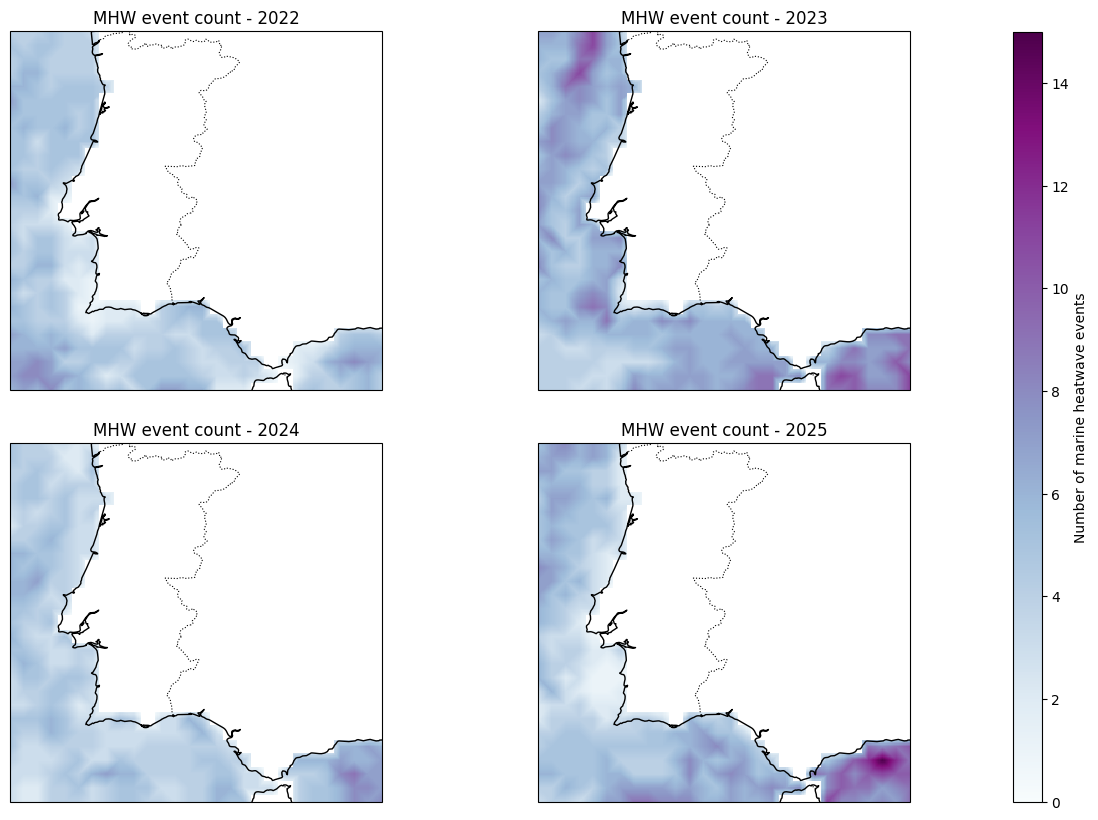

In [12]:
# Open ONE SST file (any year is fine)
ds_mask = xr.open_dataset(
    "/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2022.nc",
    engine="netcdf4",
    decode_times=True
)

# Same spatial subset as analysis
ds_mask = spatial_subset(ds_mask)

# TRUE ocean mask (True = ocean, False = land)
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

# -------------------------------------------------
# Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.06], wspace=0.15, hspace=0.15)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

# -------------------------------------------------
# Shared color scale
# -------------------------------------------------
vmin = 0
vmax = max(df["n_events"].max() for df in yearly_dfs.values())

# -------------------------------------------------
# Plot each year
# -------------------------------------------------
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lats = df["lat"].values
    lons = df["lon"].values
    counts = df["n_events"].values

    # Interpolation grid
    lon_grid = np.linspace(lons.min(), lons.max(), 300)
    lat_grid = np.linspace(lats.min(), lats.max(), 300)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------
    # Interpolate MHW counts
    # -----------------------------
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # -----------------------------
    # Interpolate TRUE land–sea mask
    # -----------------------------
    # -------------------------------------------------
    # Build lon/lat grid from the SST mask dataset
    # -------------------------------------------------
    lon2d, lat2d = np.meshgrid(
        ds_mask["lon"].values,
        ds_mask["lat"].values
    )

    # -------------------------------------------------
    # Interpolate TRUE land–sea mask
    # -------------------------------------------------
    mask_interp = griddata(
        (lon2d.ravel(), lat2d.ravel()),
        ocean_mask.values.ravel().astype(float),
        (lon_grid, lat_grid),
        method="nearest"
    )

    # Apply mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # -----------------------------
    # Map styling
    # -----------------------------
    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="BuPu",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW event count - {year}")

# -------------------------------------------------
# Colorbar (guaranteed no overlap)
# -------------------------------------------------
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")

plt.show()


KeyError: 'mean_duration'

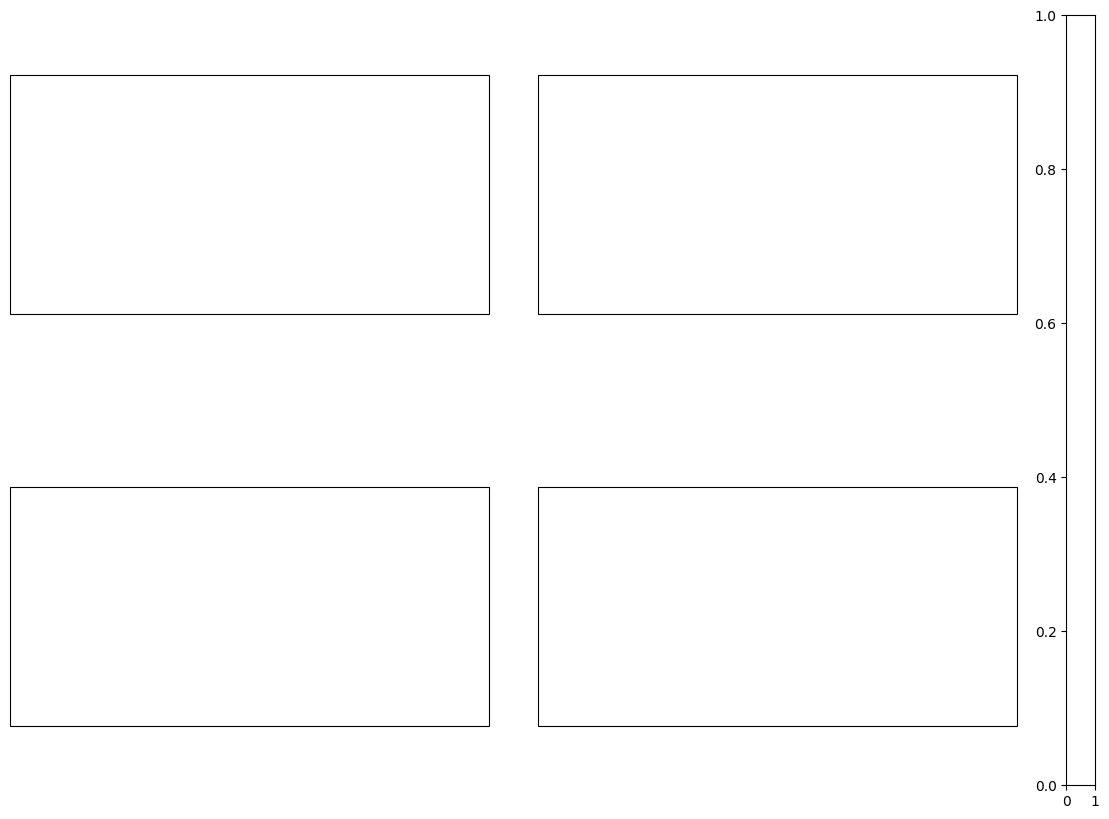

In [13]:
import xarray as xr
import numpy as np

# Open ONE SST file (any year is fine)
ds_mask = xr.open_dataset(
    "/Users/miguelsilveira/Documents/Mig Cod/oisst_daily/sst.day.mean.2022.nc",
    engine="netcdf4",
    decode_times=True
)

# Same spatial subset as analysis
ds_mask = ds_mask.sel(lon=slice(349.5, 356.5),
                      lat=slice(35.5, 42.3)
)

# TRUE ocean mask (True = ocean, False = land)
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

# -------------------------------------------------
# Figure layout (explicit, no overlap)
# -------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.06], wspace=0.15, hspace=0.15)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

# -------------------------------------------------
# Robust color scale (ignore extreme outliers)
# -------------------------------------------------
all_vals = np.concatenate([
    df["mean_duration"].values for df in yearly_dfs.values()
])

vmin = np.nanpercentile(all_vals, 5)
vmax = np.nanpercentile(all_vals, 95)


# -------------------------------------------------
# Plot each year
# -------------------------------------------------
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lats = df["lat"].values
    lons = df["lon"].values
    counts = df["mean_duration"].values

    # Interpolation grid
    lon_grid = np.linspace(lons.min(), lons.max(), 300)
    lat_grid = np.linspace(lats.min(), lats.max(), 300)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------
    # Interpolate MHW counts
    # -----------------------------
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # -----------------------------
    # Interpolate TRUE land–sea mask
    # -----------------------------
    # -------------------------------------------------
    # Build lon/lat grid from the SST mask dataset
    # -------------------------------------------------
    lon2d, lat2d = np.meshgrid(
        ds_mask["lon"].values,
        ds_mask["lat"].values
    )

    # -------------------------------------------------
    # Interpolate TRUE land–sea mask
    # -------------------------------------------------
    mask_interp = griddata(
        (lon2d.ravel(), lat2d.ravel()),
        ocean_mask.values.ravel().astype(float),
        (lon_grid, lat_grid),
        method="nearest"
    )

    # Apply mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)


    # Apply mask (THIS removes the triangle)
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # -----------------------------
    # Map styling
    # -----------------------------
    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="BuPu",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW event count – {year}")

# -------------------------------------------------
# Colorbar (guaranteed no overlap)
# -------------------------------------------------
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")


plt.show()

In [ ]:
'''mhw_ev,clim = mhw.detect(y2023_time_ord, y2023_sst, 
                         climatologyPeriod=[1991, 2021],
                         alternateClimatology= [baseline_time_ord, baseline_sst])'''

'mhw_ev,clim = mhw.detect(y2023_time_ord, y2023_sst, \n                         climatologyPeriod=[1991, 2021],\n                         alternateClimatology= [baseline_time_ord, baseline_sst])'

In [ ]:
'''mhw_ev['n_events']'''

"mhw_ev['n_events']"